<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 決定木

In [1]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 24.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=9dc06dd0b522c587b74fea40acb1695ac6be7166197d227815a20236d7677468
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## 基本的な訓練と評価

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# ────────────────────────
# データの準備
# ────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ────────────────────────
# モデルの構築と学習
# 注：決定木はスケーリング不要
# ────────────────────────
dt = DecisionTreeClassifier(
    criterion='gini',           # 分割基準（'gini' or 'entropy'）
    max_depth=4,                # 最大深さ
    min_samples_split=5,        # 分割に必要な最小サンプル数
    min_samples_leaf=2,         # 葉ノードの最小サンプル数
    random_state=42
)
dt.fit(X_train, y_train)

# ────────────────────────
# 予測と評価
# ────────────────────────
y_pred = dt.predict(X_test)

print(f"正解率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(
    y_test, y_pred, target_names=iris.target_names
))


正解率 (Accuracy): 0.8889

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



## 木の可視化 ─ モデルの判断過程を見る

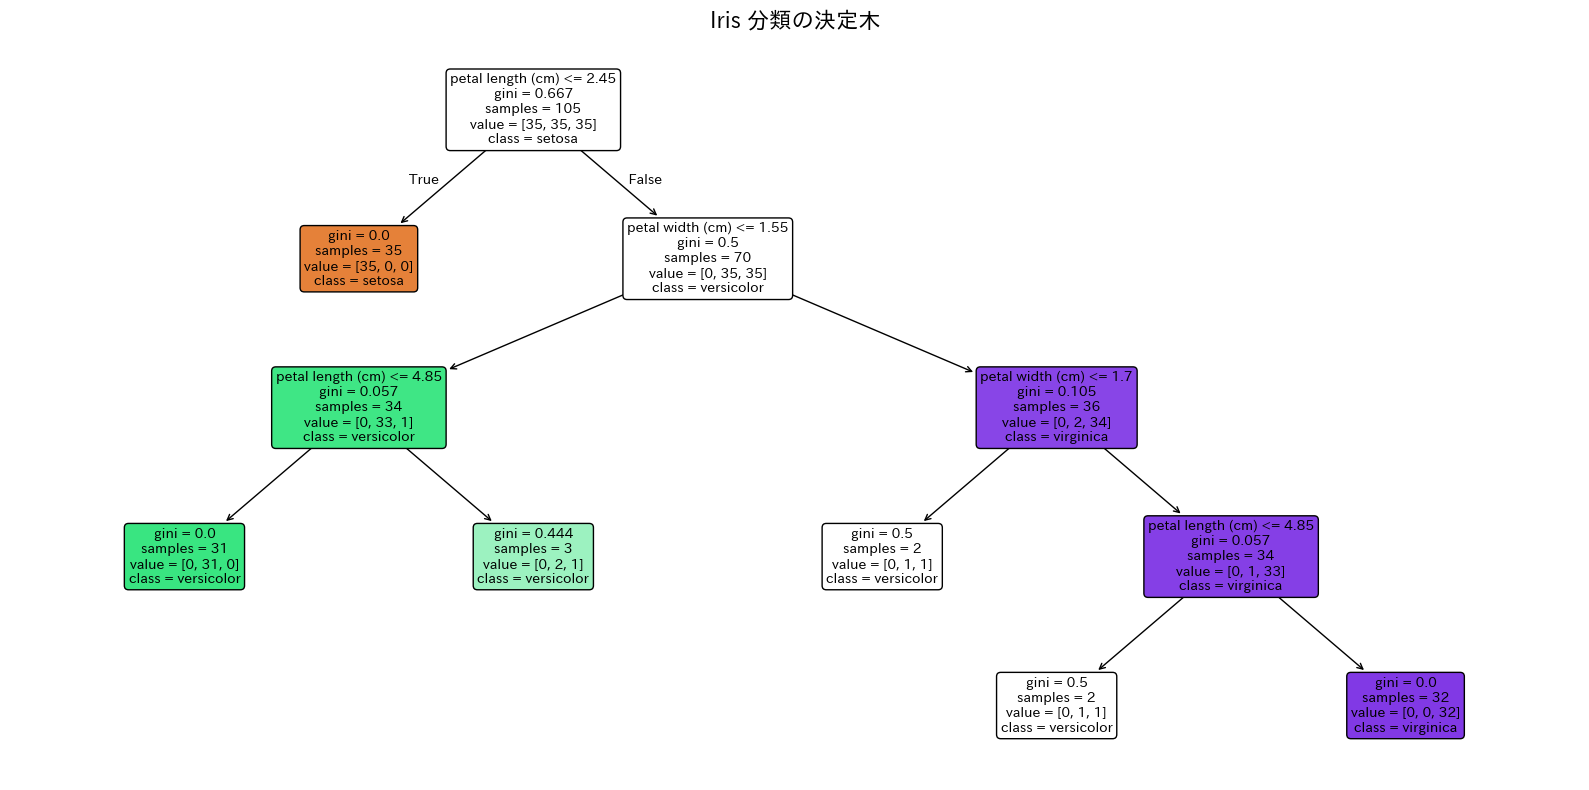

=== 決定木のルール（テキスト形式） ===

|--- petal length (cm) <= 2.45
|   |--- weights: [35.00, 0.00, 0.00] class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- weights: [0.00, 31.00, 0.00] class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- weights: [0.00, 2.00, 1.00] class: 1
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- weights: [0.00, 1.00, 1.00] class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- weights: [0.00, 1.00, 1.00] class: 1
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- weights: [0.00, 0.00, 32.00] class: 2



In [4]:
from sklearn import tree
import matplotlib.pyplot as plt
import japanize_matplotlib

# 方法 1：matplotlib による可視化
fig, ax = plt.subplots(figsize=(16, 8))
tree.plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,            # クラスごとに色分け
    rounded=True,           # ノードの角を丸める
    fontsize=10,
    ax=ax
)
plt.title('Iris 分類の決定木', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# 方法 2：テキスト形式での表示
print("=== 決定木のルール（テキスト形式） ===\n")
print(tree.export_text(
    dt,
    feature_names=iris.feature_names,
    show_weights=True
))


## 特徴量重要度の確認

=== 特徴量重要度 ===

  petal length (cm)   : 0.5482
  petal width (cm)    : 0.4518
  sepal width (cm)    : 0.0000
  sepal length (cm)   : 0.0000


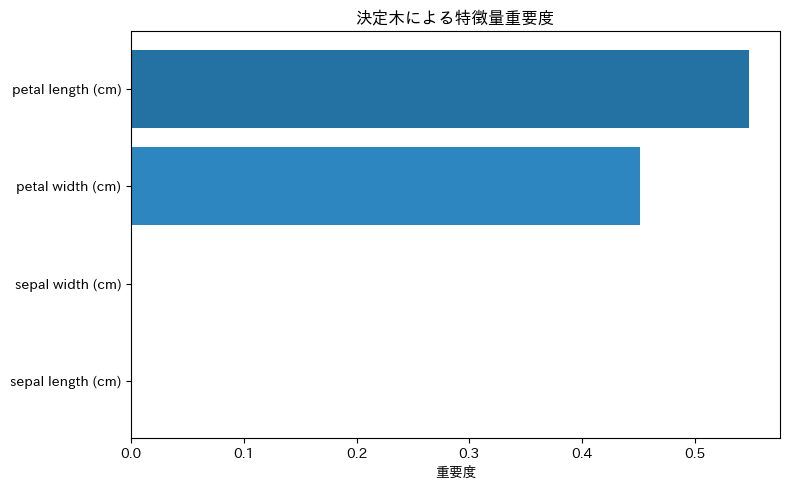

In [6]:
# 重要度は feature_importance_ に保存されている
importances = dt.feature_importances_
feature_names = iris.feature_names

# 重要度順にソートして表示
sorted_idx = np.argsort(importances)[::-1]
print("=== 特徴量重要度 ===\n")
for idx in sorted_idx:
    print(f"  {feature_names[idx]:20s}: {importances[idx]:.4f}")

# 棒グラフによる可視化
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    range(len(importances)),
    importances[sorted_idx],
    color=['#2471A3', '#2E86C1', '#85C1E9', '#D4E6F1']
)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('重要度')
ax.set_title('決定木による特徴量重要度')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## 過学習の可視化 ─ 深さと精度の関係

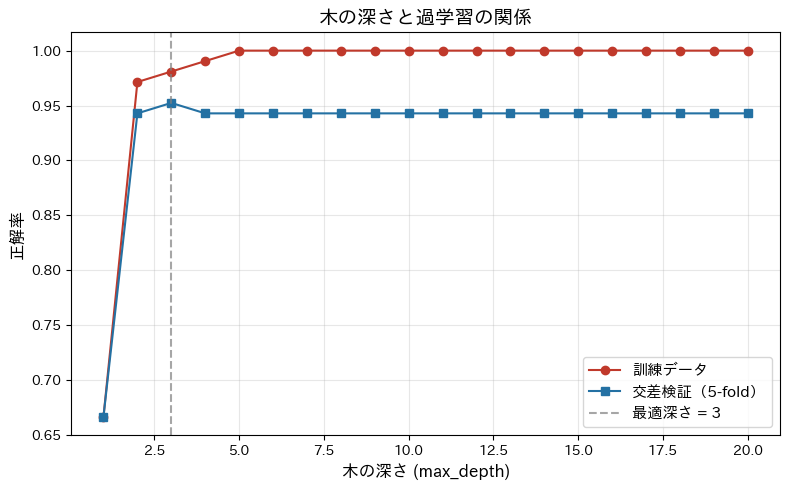

In [7]:
from sklearn.model_selection import cross_val_score

depths = range(1, 21)
train_scores = []
cv_scores = []

for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_train, y_train)
    train_scores.append(dt_d.score(X_train, y_train))
    cv = cross_val_score(dt_d, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_scores, 'o-', color='#C0392B', label='訓練データ')
ax.plot(depths, cv_scores, 's-', color='#2471A3', label='交差検証（5-fold）')
ax.axvline(
    x=depths[np.argmax(cv_scores)],
    color='gray', linestyle='--', alpha=0.7,
    label=f'最適深さ = {depths[np.argmax(cv_scores)]}'
)
ax.set_xlabel('木の深さ (max_depth)', fontsize=12)
ax.set_ylabel('正解率', fontsize=12)
ax.set_title('木の深さと過学習の関係', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('depth_vs_accuracy.png', dpi=150)
plt.show()


## コスト複雑度剪定（事後剪定）

最適な ccp_alpha = 0.000000
交差検証スコア   = 0.9429
テスト正解率     = 0.9333
葉ノード数       = 8
木の深さ         = 5


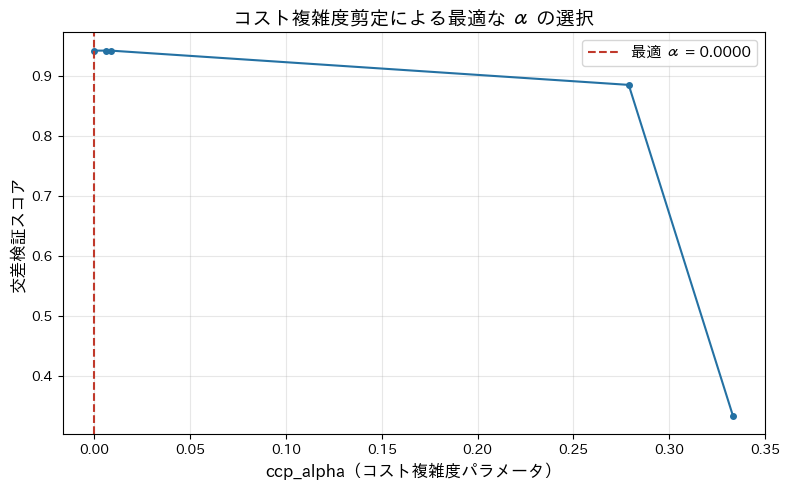

In [8]:
# 剪定パスの取得
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # 候補の alpha 値
impurities = path.impurities   # 対応する不純度

# 各 alpha での交差検証スコア
cv_scores_alpha = []
for alpha in ccp_alphas:
    dt_a = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(dt_a, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_alpha.append(scores.mean())

# 最適な alpha の特定
best_alpha_idx = np.argmax(cv_scores_alpha)
best_alpha = ccp_alphas[best_alpha_idx]
print(f"最適な ccp_alpha = {best_alpha:.6f}")
print(f"交差検証スコア   = {cv_scores_alpha[best_alpha_idx]:.4f}")

# 最適な alpha で再学習
dt_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
dt_pruned.fit(X_train, y_train)
y_pred_pruned = dt_pruned.predict(X_test)
print(f"テスト正解率     = {accuracy_score(y_test, y_pred_pruned):.4f}")
print(f"葉ノード数       = {dt_pruned.get_n_leaves()}")
print(f"木の深さ         = {dt_pruned.get_depth()}")

# プロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ccp_alphas, cv_scores_alpha, 'o-', color='#2471A3', markersize=4)
ax.axvline(x=best_alpha, color='#C0392B', linestyle='--',
           label=f'最適 α = {best_alpha:.4f}')
ax.set_xlabel('ccp_alpha（コスト複雑度パラメータ）', fontsize=12)
ax.set_ylabel('交差検証スコア', fontsize=12)
ax.set_title('コスト複雑度剪定による最適な α の選択', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ccp_alpha_selection.png', dpi=150)
plt.show()


## 決定境界の可視化（深さによる変化）

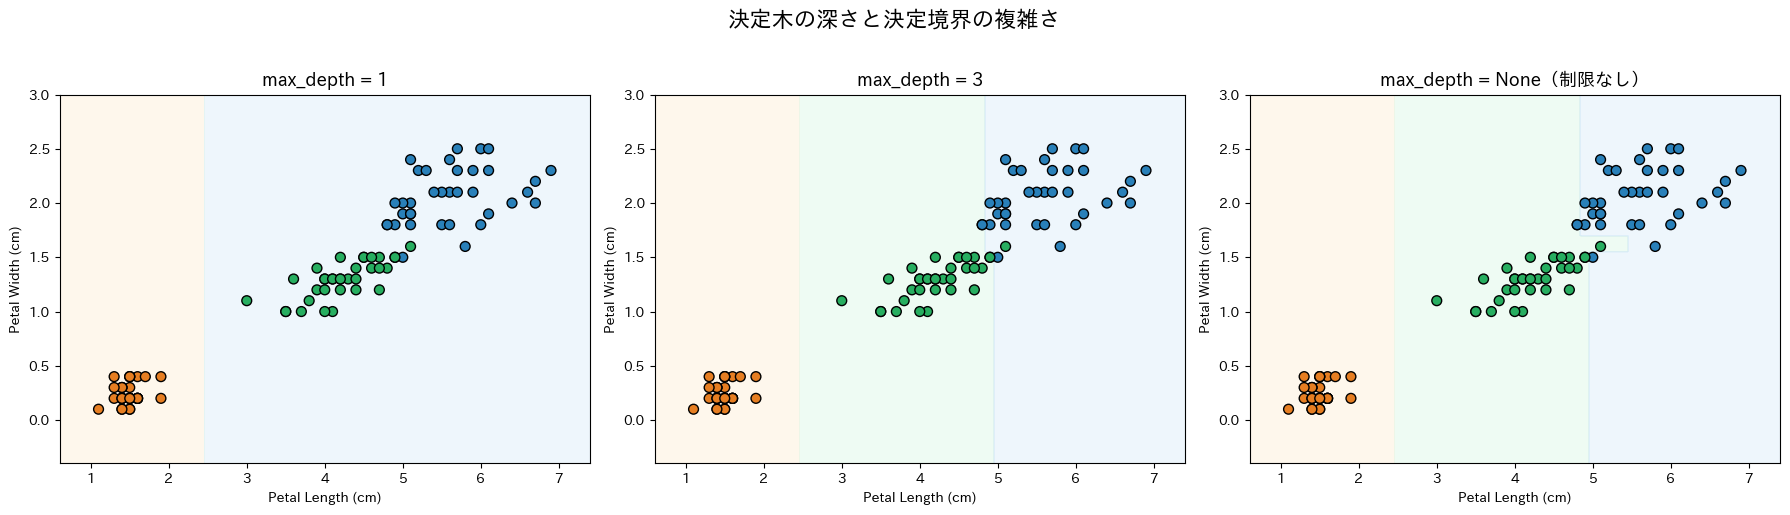

In [9]:
from matplotlib.colors import ListedColormap

# 2特徴量に限定
X_vis = iris.data[:, 2:4]
y_vis = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)

x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, depth in zip(axes, [1, 3, None]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_tr, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cmap_pt,
               edgecolors='k', s=50)
    title = f'max_depth = {depth}' if depth else 'max_depth = None（制限なし）'
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')

plt.suptitle('決定木の深さと決定境界の複雑さ', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('dt_decision_boundaries.png', dpi=150)
plt.show()


## 不安定性の実証 ─ データのわずかな変化で木が変わる

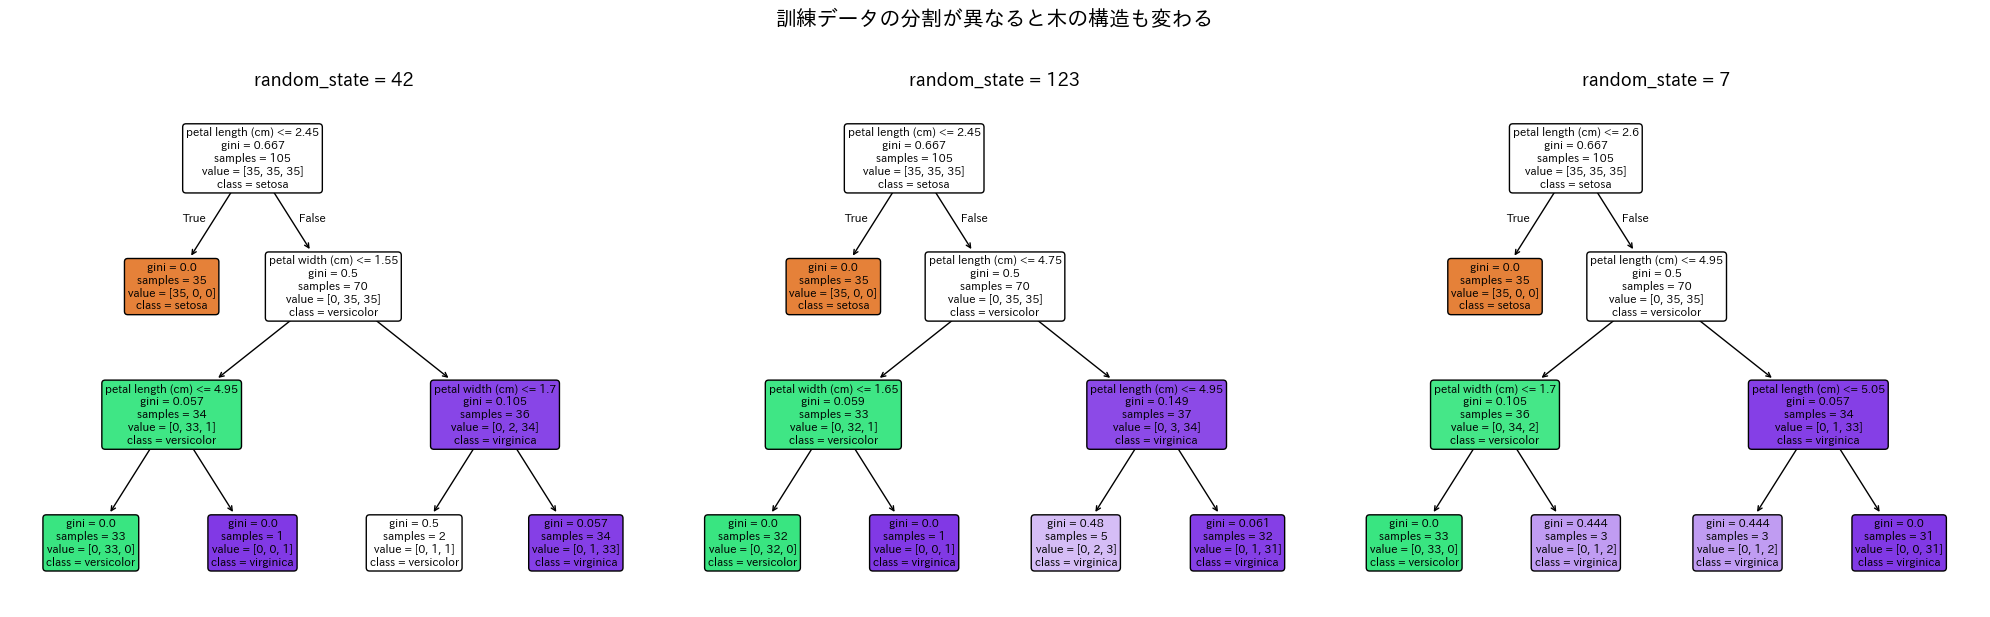

In [10]:
# 異なるランダムシードでデータを分割し，木構造を比較
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, seed in zip(axes, [42, 123, 7]):
    X_tr_s, _, y_tr_s, _ = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    dt_s = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt_s.fit(X_tr_s, y_tr_s)
    tree.plot_tree(dt_s, feature_names=iris.feature_names,
                   class_names=iris.target_names,
                   filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title(f'random_state = {seed}', fontsize=13)

plt.suptitle('訓練データの分割が異なると木の構造も変わる', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('dt_instability.png', dpi=150)
plt.show()

# → この不安定性がランダムフォレストなどのアンサンブル手法を動機づける


## 分割基準の比較（Gini vs Entropy）

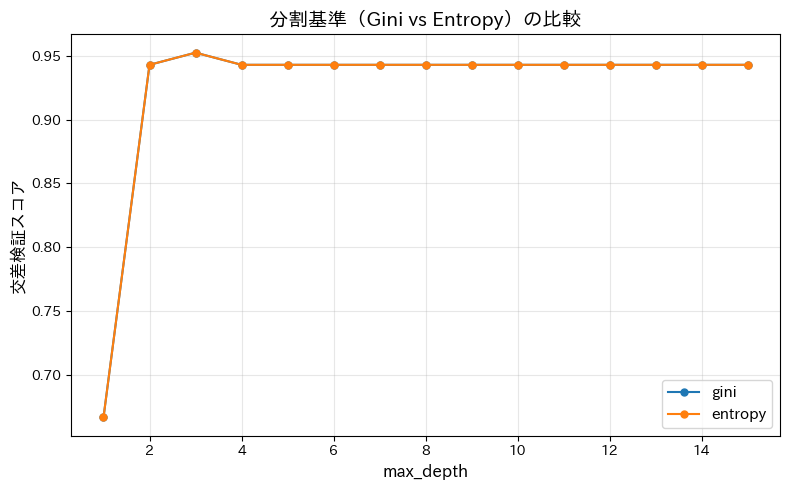

In [11]:
criteria = ['gini', 'entropy']
depths = range(1, 16)

fig, ax = plt.subplots(figsize=(8, 5))
for criterion in criteria:
    scores = []
    for d in depths:
        dt_c = DecisionTreeClassifier(
            criterion=criterion, max_depth=d, random_state=42
        )
        cv = cross_val_score(dt_c, X_train, y_train, cv=5, scoring='accuracy')
        scores.append(cv.mean())
    ax.plot(depths, scores, 'o-', label=criterion, markersize=5)

ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('交差検証スコア', fontsize=12)
ax.set_title('分割基準（Gini vs Entropy）の比較', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gini_vs_entropy.png', dpi=150)
plt.show()

# 多くの場合，両者の性能差はほとんどない
